# Recommender System for a Medical Supplies Company

<img src='https://online.abertay.ac.uk/wp-content/uploads/2023/06/recommender-systems.jpg' width='750'>

### Project Purpose and Scope

The main objective of this project is to implement data-driven recommender systems to help the company generate incremental sales and revenue. As part of the project, the dataset was first cleaned and missing values were handled. Next, the top-performing products were analyzed based on both sales volume and financial value (dollar amount), and the corporate customers with the highest purchases were identified.

In the modeling phase, three different approaches were combined:

1. **Popularity-Based Model:** Delivers recommendations based on overall sales trends.

2.  **Matrix Factorization:** Generates personalized collaborative filtering recommendations by analyzing user-product interactions.

3. **Cosine Similarity:** Provides content-based recommendations for similar items by processing product descriptions using text mining techniques.

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Reading Data
df=pd.read_csv('PBL 5 recommendation data.csv', encoding='latin1')

### EDA

In [3]:
df.head()

,Customers.id,Customers.fname,Customers.lname,Customers.company,Customers.create_date,Customers.status,Customers.mailing,Customers.reminders,Customers.tax_exempt,Customers.account_id,...,Products.google_shopping_label,Products.product_option,Products.size,Products.material,Products.arm_style,Products.leg_style,Products.seat_size,Products.family_id,Products.saved_status,Products.freight_cost
0,797,Christy,Dill,Company0,1426018724,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF61071,0.0,NaN
1,3,John,Smith,Company1,1386089139,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF02132,NaN,NaN
2,3,John,Smith,Company1,1386089139,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2 x Extra large,Nitrile,NaN,NaN,NaN,PF00342,0.0,NaN
3,4,James,Anderson,NaN,1386780263,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF04970,NaN,NaN
4,5,Abraham,Pollak,Company3,1386861599,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF03045,NaN,NaN


In [4]:
df.tail()

,Customers.id,Customers.fname,Customers.lname,Customers.company,Customers.create_date,Customers.status,Customers.mailing,Customers.reminders,Customers.tax_exempt,Customers.account_id,...,Products.google_shopping_label,Products.product_option,Products.size,Products.material,Products.arm_style,Products.leg_style,Products.seat_size,Products.family_id,Products.saved_status,Products.freight_cost
4189,3730,Nora,Fontana,NaN,1463408698,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,Plastic Rim,NaN,NaN,NaN,PF06157,3.0,NaN
4190,3732,Kennithe,Tecora,NaN,1463412756,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PF08485,3.0,NaN
4191,3733,Tinna,Randall,NaN,1463413245,NaN,NaN,NaN,NaN,NaN,...,NaN,21AH Batteries,NaN,NaN,NaN,NaN,NaN,PM36,3.0,NaN
4192,3735,HALIMAH,SHAHID,NaN,1463416687,NaN,1.0,NaN,NaN,NaN,...,5.0,NaN,NaN,Aluminum,NaN,NaN,NaN,PF04829,3.0,NaN
4193,3736,Michael,Kiernan,NaN,1463418049,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,Large,NaN,NaN,NaN,NaN,PF03816,3.0,NaN


In [5]:
df.columns

Index(['Customers.id', 'Customers.fname', 'Customers.lname',
       'Customers.company', 'Customers.create_date', 'Customers.status',
       'Customers.mailing', 'Customers.reminders', 'Customers.tax_exempt',
       'Customers.account_id',
       ...
       'Products.google_shopping_label', 'Products.product_option',
       'Products.size', 'Products.material', 'Products.arm_style',
       'Products.leg_style', 'Products.seat_size', 'Products.family_id',
       'Products.saved_status', 'Products.freight_cost'],
      dtype='object', length=181)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4194 entries, 0 to 4193
Columns: 181 entries, Customers.id to Products.freight_cost
dtypes: float64(98), int64(10), object(73)
memory usage: 5.8+ MB


In [7]:
df.shape

(4194, 181)

In [8]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', None)

In [9]:
df.isnull().sum().sort_values()

Customers.id                         0
Order_Items.id                       0
Orders.subtotal                      0
Orders.currency                      0
Orders.order_number                  0
Orders.lname                         0
Orders.customer_id                   0
Orders.id                            0
Customers.last_modified              0
Order_Items.price                    0
Order_Items.qty                      0
Orders.fname                         0
Orders.total                         0
Orders.status                        0
Customers.fname                      0
Orders.placed_date                   0
Customers.lname                      0
Order_Items.parent                   0
Order_Items.product_name             0
Customers.create_date                0
Order_Items.cost                     3
Orders.payment_status                5
Orders.payment_date                 18
Orders.payment_amount               18
Orders.updated_date                 23
Order_Items.product_id   

In [10]:
missing_df = pd.DataFrame(
    {
        'count': df.isnull().sum(),
        'percent': (df.isnull().mean() * 100).round(2),
    }
).sort_values('percent', ascending=False)

print(missing_df.to_string())

                                count  percent
Products.freight_cost            4194   100.00
Orders.mailing                   4194   100.00
Orders.gift_message              4194   100.00
Orders.registry_id               4194   100.00
Products.right_flag              4194   100.00
Orders.sales_rep                 4194   100.00
Products.markup                  4194   100.00
Orders.payment_ref               4194   100.00
Products.websites                4194   100.00
Orders.purchase_order            4194   100.00
Orders.gift_id                   4194   100.00
Orders.gift_amount               4194   100.00
Products.price_breaks            4194   100.00
Products.seo_footer              4194   100.00
Products.default_quantity        4194   100.00
Orders.shipping_flags            4194   100.00
Products.price_break_type        4194   100.00
Orders.shipping_trans            4194   100.00
Orders.website                   4194   100.00
Products.amazon_type             4194   100.00
Order_Items.a

In [11]:
cols_to_drop = [
    'Products.freight_cost', 'Orders.mailing', 'Orders.gift_message', 'Orders.registry_id',    #We removed useless columns that were 70% or more empty.             
    'Products.right_flag', 'Orders.sales_rep', 'Products.markup', 'Orders.payment_ref',
    'Products.websites', 'Orders.purchase_order', 'Orders.gift_id', 'Orders.gift_amount',
    'Products.price_breaks', 'Products.seo_footer', 'Products.default_quantity', 'Orders.shipping_flags',
    'Products.price_break_type', 'Orders.shipping_trans', 'Orders.website', 'Products.amazon_type',
    'Order_Items.account_id', 'Order_Items.attributes', 'Order_Items.attribute_prices', 'Products.menu_name',
    'Order_Items.registry_item', 'Order_Items.related_id', 'Customers.profile_id', 'Customers.rewards',
    'Customers.sales_rep', 'Products.product_type', 'Products.audio', 'Products.leg_style',
    'Customers.reminders', 'Products.google_adwords', 'Orders.flags', 'Products.features_title',
    'Products.shopping_age', 'Orders.weight', 'Customers.account_id', 'Customers.tax_exempt',
    'Orders.external_id', 'Products.seo_header', 'Products.display_packaging', 'Order_Items.reorder_frequency',
    'Order_Items.attribute_names', 'Orders.reorder_id', 'Orders.partial_ship', 'Customers.status',
    'Products.map_price', 'Products.arm_style', 'Products.seat_size', 'Products.rotation_link',
    'Orders.fee_name', 'Products.shopping_gender', 'Orders.fee_amount', 'Orders.discount_name',
    'Orders.comments', 'Products.product_option', 'Orders.balance_due', 'Orders.discount_amount',
    'Orders.external_source', 'Products.google_shopping_label', 'Products.notes', 'Products.seo_description',
    'Products.amazon_price', 'Products.installation', 'Products.user_size', 'Products.assembly',
    'Products.msds_link', 'Products.rx', 'Products.msds_label', 'Products.shipping_weight',
    'Products.warranty', 'Products.video', 'Orders.payment_method', 'Products.material',
    'Orders.coupon_id', 'Orders.coupon_amount', 'Products.height', 'Products.width',
    'Products.handling_time', 'Products.length', 'Order_Items.flags', 'Products.seo_keywords',
    'Products.sale_price', 'Products.left_flag'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

In [12]:
df.shape

(4194, 95)

In [13]:
df.isnull().sum().sort_values()

Customers.id                        0
Orders.placed_date                  0
Orders.status                       0
Order_Items.parent                  0
Order_Items.product_name            0
Order_Items.qty                     0
Order_Items.price                   0
Orders.total                        0
Orders.subtotal                     0
Orders.currency                     0
Orders.order_number                 0
Order_Items.id                      0
Orders.fname                        0
Orders.customer_id                  0
Orders.id                           0
Customers.fname                     0
Customers.lname                     0
Customers.last_modified             0
Orders.lname                        0
Customers.create_date               0
Order_Items.cost                    3
Orders.payment_status               5
Orders.payment_date                18
Orders.payment_amount              18
Orders.updated_date                23
Order_Items.product_id             43
Products.seo

In [14]:
# Stage 2: We delete non-functional, system/logistics/SEO-focused columns.
secondary_drops = [
    # SEO and Marketing Channels
    'Products.seo_url', 'Products.seo_title', 'Products.seo_category',
    'Products.google_shopping_cat', 'Products.google_shopping_type', 'Products.google_shopping_id',
    'Products.shopping_mpn', 'Products.shopping_brand', 'Products.shopping_flags', 
    'Products.shopping_cat', 'Products.shopping_type', 'Products.pricegrabber_cat', 
    'Products.shopzilla_cat', 'Products.thefind_cat', 'Products.amazon_item_type', 'Products.amazon_asin',
    
    # Technical / Integration Codes
    'Products.quickbooks_id', 'Products.qb_edit_sequence', 'Products.import_id', 
    'Products.template', 'Products.saved_status', 'Products.hcpcs', 'Products.shopping_gtin', 
    'Products.upc', 'Products.family_id', 'Products.import_flags', 'Products.flags',
    
    # Cargo and Logistics
    'Products.shipping_length', 'Products.shipping_height', 'Products.shipping_width',
    'Orders.tracking', 'Orders.shipping_method', 'Orders.shipping_carrier', 'Orders.shipped_date',
    'Orders.shipping',
    
    # Payment and System Dates
    'Orders.payment_type', 'Orders.payment_id', 'Orders.payment_code', 'Orders.payment_user', 
    'Orders.payment_status', 'Orders.payment_date', 'Orders.payment_amount', 'Orders.updated_date', 
    'Customers.last_modified', 'Customers.create_date', 'Products.last_modified',
    
    # Names and Unnecessary Text
    'Orders.fname', 'Orders.lname', 'Customers.fname', 'Customers.lname', 'Orders.notes', 
    'Orders.currency', 'Customers.mailing', 'Products.lit_link', 'Products.lit_label',
    'Products.display_name', 'Products.hygienic', 'Products.latex'
]

# We are deleting the columns
df = df.drop(columns=secondary_drops, errors='ignore')

In [15]:
df.shape

(4194, 37)

In [16]:
df.isnull().sum().sort_values()

Customers.id                     0
Order_Items.qty                  0
Order_Items.product_name         0
Order_Items.parent               0
Order_Items.id                   0
Orders.placed_date               0
Orders.status                    0
Orders.total                     0
Order_Items.price                0
Orders.subtotal                  0
Orders.order_number              0
Orders.customer_id               0
Orders.id                        0
Order_Items.cost                 3
Order_Items.product_id          43
Products.cost                  157
Products.name                  157
Products.status                157
Products.id                    157
Products.vendor                157
Products.price                 158
Products.list_price            177
Orders.customer_type           183
Products.long_description      186
Products.unit                  209
Customers.customer_type        423
Orders.tax                     457
Products.short_description    1179
Products.multiple   

In [17]:
cols_to_drop = [
    # High missing values & non-essential physical attributes
    'Products.shopping_color',  # 2494 missing values
    'Products.size',            # 2751 missing values
    
    # Operational & logistics details (NOT relevant for recommender systems or sales analysis)
    'Products.packaging',       # 1304 missing values
    'Products.case_qty',        # 1556 missing values
    'Products.override_markup', # 1274 missing values
    'Products.multiple',        # 1230 missing values
    'Products.taxable',         # 1235 missing values
    'Products.unit'             # 209 missing values
]

# Drop unwanted columns
df = df.drop(columns=cols_to_drop)

In [18]:
df.shape

(4194, 29)

In [19]:
df.isnull().sum().sort_values()

Customers.id                     0
Order_Items.price                0
Order_Items.qty                  0
Order_Items.product_name         0
Order_Items.id                   0
Orders.placed_date               0
Orders.status                    0
Orders.total                     0
Order_Items.parent               0
Orders.subtotal                  0
Orders.order_number              0
Orders.customer_id               0
Orders.id                        0
Order_Items.cost                 3
Order_Items.product_id          43
Products.cost                  157
Products.name                  157
Products.id                    157
Products.status                157
Products.vendor                157
Products.price                 158
Products.list_price            177
Orders.customer_type           183
Products.long_description      186
Customers.customer_type        423
Orders.tax                     457
Products.short_description    1179
Orders.company                3466
Customers.company   

In [20]:
df.describe()

,Customers.id,Customers.customer_type,Orders.id,Orders.customer_id,Orders.subtotal,Orders.tax,Orders.total,Orders.status,Orders.placed_date,Orders.customer_type,Order_Items.id,Order_Items.parent,Order_Items.product_id,Order_Items.qty,Order_Items.price,Order_Items.cost,Products.id,Products.status,Products.vendor,Products.list_price,Products.price,Products.cost
count,4194.000000,3771.000000,4194.000000,4194.000000,4194.000000,3737.000000,4194.000000,4194.000000,4.194000e+03,4011.000000,4194.000000,4194.000000,4151.000000,4194.000000,4194.000000,4191.000000,4037.000000,4037.000000,4037.000000,4017.000000,4036.000000,4037.000000
mean,1796.518121,0.137364,9142.984025,1796.518121,131.925196,0.800838,137.192818,1.326180,1.443054e+09,0.124159,11156.068670,9142.984025,4451.426162,1.858846,67.349132,51.112718,4518.398068,0.987119,1.629676,121.683321,74.266043,52.318192
std,1065.679090,0.391842,5276.541078,1065.679090,231.156869,4.859280,222.898475,1.508683,1.814291e+07,0.375087,5802.466202,5276.541078,5577.392427,8.821959,95.571793,74.155515,5614.454744,1.386196,1.420626,245.856090,98.829781,74.691642
min,3.000000,0.000000,23.000000,3.000000,2.890000,0.000000,2.890000,0.000000,1.386090e+09,0.000000,31.000000,23.000000,1.000000,1.000000,1.120000,0.280000,1.000000,0.000000,1.000000,1.020000,1.540000,0.280000
25%,865.250000,0.000000,4258.000000,865.250000,36.750000,0.000000,44.110000,1.000000,1.431802e+09,0.000000,5847.250000,4258.000000,1009.000000,1.000000,24.030000,16.200000,1012.000000,0.000000,1.000000,33.110000,24.400000,15.500000
50%,1747.500000,0.000000,9641.000000,1747.500000,74.740000,0.000000,80.510000,1.000000,1.449675e+09,0.000000,11770.000000,9641.000000,1867.000000,1.000000,43.460000,32.500000,1867.000000,0.000000,1.000000,72.330000,48.245000,31.750000
75%,2698.750000,0.000000,14011.750000,2698.750000,139.960000,0.000000,143.855000,1.000000,1.457727e+09,0.000000,16482.750000,14011.750000,4345.500000,1.000000,74.990000,59.500000,4371.000000,3.000000,2.000000,134.390000,83.360000,59.990000
max,3736.000000,2.000000,17437.000000,3736.000000,5163.040000,132.930000,4627.950000,15.000000,1.463419e+09,2.000000,20202.000000,17437.000000,26175.000000,500.000000,1899.000000,1350.000000,26175.000000,5.000000,11.000000,8439.000000,1899.000000,1350.000000


In [21]:
df.corr(numeric_only=True)

,Customers.id,Customers.customer_type,Orders.id,Orders.customer_id,Orders.subtotal,Orders.tax,Orders.total,Orders.status,Orders.placed_date,Orders.customer_type,Order_Items.id,Order_Items.parent,Order_Items.product_id,Order_Items.qty,Order_Items.price,Order_Items.cost,Products.id,Products.status,Products.vendor,Products.list_price,Products.price,Products.cost
Customers.id,1.000000,0.363692,0.931931,1.000000,-0.032623,-0.040149,-0.037907,0.168347,0.885630,0.320346,0.931643,0.931931,0.399430,-0.002762,-0.040332,-0.047251,0.396045,0.071312,0.294253,-0.054290,-0.058560,-0.058923
Customers.customer_type,0.363692,1.000000,0.357407,0.363692,0.003044,-0.029548,0.001774,0.087517,0.305989,0.989429,0.355335,0.357407,0.161298,-0.011297,0.014796,0.013320,0.156082,-0.028837,0.101467,-0.012243,0.001668,0.005810
Orders.id,0.931931,0.357407,1.000000,0.931931,0.008059,-0.049067,0.004189,0.162735,0.940789,0.317257,0.999385,1.000000,0.396511,0.008596,-0.054796,-0.062192,0.392546,0.024127,0.266936,-0.068610,-0.078637,-0.074643
Orders.customer_id,1.000000,0.363692,0.931931,1.000000,-0.032623,-0.040149,-0.037907,0.168347,0.885630,0.320346,0.931643,0.931931,0.399430,-0.002762,-0.040332,-0.047251,0.396045,0.071312,0.294253,-0.054290,-0.058560,-0.058923
Orders.subtotal,-0.032623,0.003044,0.008059,-0.032623,1.000000,0.177628,0.997013,0.075186,0.018234,-0.010004,0.008447,0.008059,-0.029741,0.391748,0.418261,0.415581,-0.031715,-0.064276,-0.010272,0.366307,0.400565,0.410412
Orders.tax,-0.040149,-0.029548,-0.049067,-0.040149,0.177628,1.000000,0.199910,0.001236,-0.042463,-0.028662,-0.048450,-0.049067,-0.033291,-0.007837,0.251157,0.242605,-0.029728,0.016094,-0.000327,0.346429,0.258188,0.253854
Orders.total,-0.037907,0.001774,0.004189,-0.037907,0.997013,0.199910,1.000000,0.077309,0.015483,-0.011299,0.004608,0.004189,-0.031029,0.384124,0.428587,0.425841,-0.033032,-0.069803,-0.011719,0.380704,0.412019,0.422208
Orders.status,0.168347,0.087517,0.162735,0.168347,0.075186,0.001236,0.077309,1.000000,0.122406,0.065587,0.160569,0.162735,0.132110,0.060926,0.002314,0.002965,0.132106,0.013445,0.159453,0.004119,0.003120,0.003804
Orders.placed_date,0.885630,0.305989,0.940789,0.885630,0.018234,-0.042463,0.015483,0.122406,1.000000,0.274467,0.946331,0.940789,0.368807,0.007887,-0.045089,-0.054021,0.366925,0.006793,0.235543,-0.065044,-0.073439,-0.068766
Orders.customer_type,0.320346,0.989429,0.317257,0.320346,-0.010004,-0.028662,-0.011299,0.065587,0.274467,1.000000,0.315564,0.317257,0.131314,-0.009475,0.007971,0.006895,0.126888,-0.026513,0.073031,-0.013746,-0.003395,-0.000005


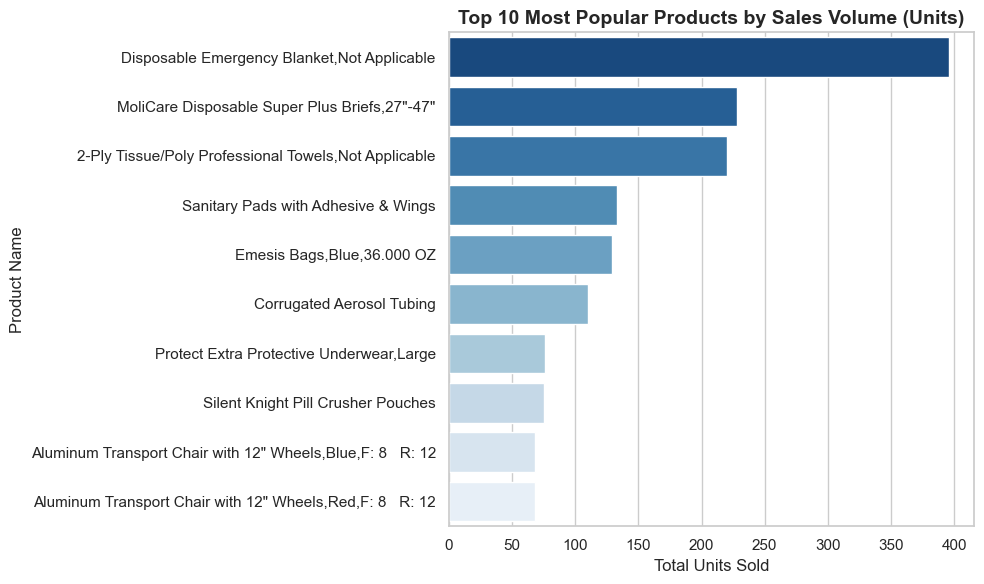

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Aggregate total quantity sold per product
top_volume_products = (
    df.groupby('Products.name')['Order_Items.qty']
    .sum()
    .nlargest(10)
    .reset_index()
)

# Plot bar chart
sns.barplot(
    data=top_volume_products, 
    x='Order_Items.qty', 
    y='Products.name', 
    palette='Blues_r'
)

plt.title('Top 10 Most Popular Products by Sales Volume (Units)', fontsize=14, fontweight='bold')
plt.xlabel('Total Units Sold', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

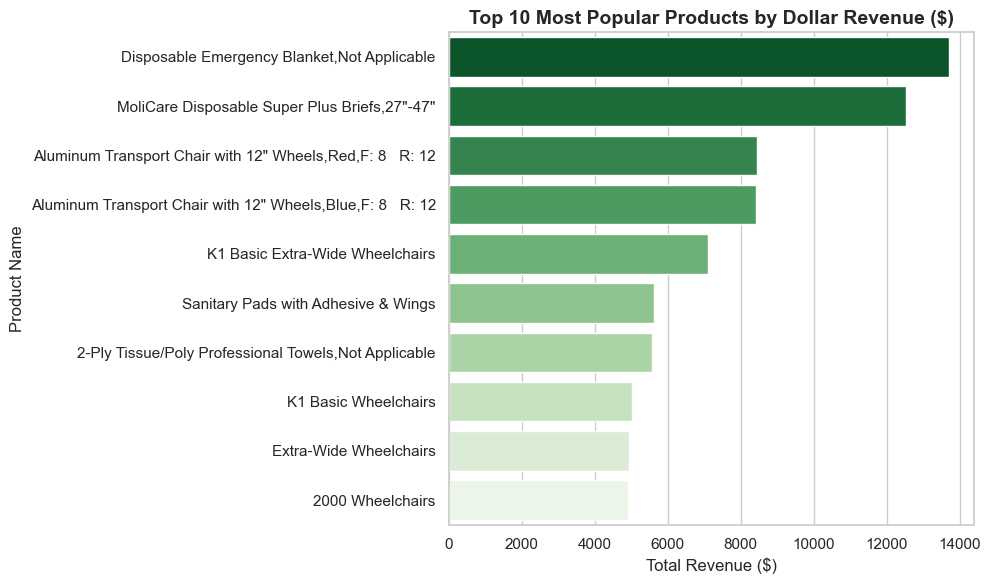

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total revenue per order item
df['total_revenue'] = df['Order_Items.qty'] * df['Order_Items.price']

plt.figure(figsize=(10, 6))

# Aggregate total revenue per product
top_revenue_products = (
    df.groupby('Products.name')['total_revenue']
    .sum()
    .nlargest(10)
    .reset_index()
)

# Plot bar chart
sns.barplot(
    data=top_revenue_products, 
    x='total_revenue', 
    y='Products.name', 
    palette='Greens_r'
)

plt.title('Top 10 Most Popular Products by Dollar Revenue ($)', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

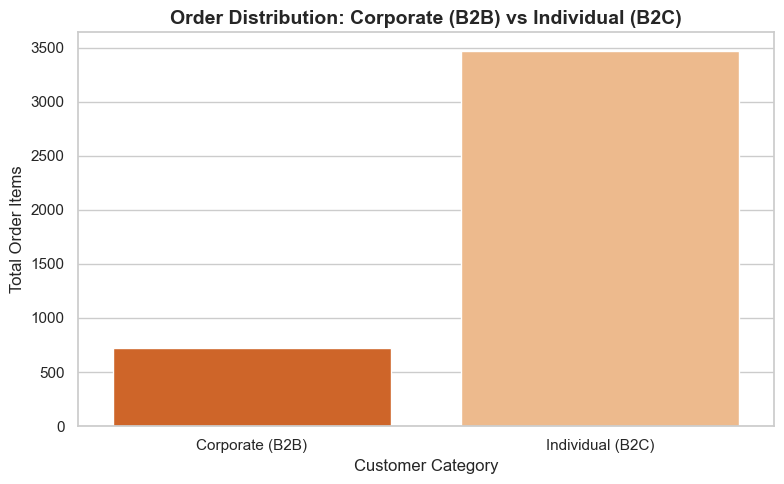

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Categorize customer based on presence of company name
df['customer_category'] = df['Customers.company'].apply(
    lambda x: 'Corporate (B2B)' if pd.notnull(x) else 'Individual (B2C)'
)

plt.figure(figsize=(8, 5))

# Plot count of orders by customer type
sns.countplot(
    data=df, 
    x='customer_category', 
    palette='Oranges_r'
)

plt.title('Order Distribution: Corporate (B2B) vs Individual (B2C)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Category', fontsize=12)
plt.ylabel('Total Order Items', fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
df.isnull().sum().sort_values()

Customers.id                     0
Order_Items.price                0
Order_Items.qty                  0
Order_Items.product_name         0
total_revenue                    0
Order_Items.parent               0
Order_Items.id                   0
Orders.placed_date               0
Orders.status                    0
customer_category                0
Orders.subtotal                  0
Orders.order_number              0
Orders.customer_id               0
Orders.id                        0
Orders.total                     0
Order_Items.cost                 3
Order_Items.product_id          43
Products.cost                  157
Products.name                  157
Products.vendor                157
Products.status                157
Products.id                    157
Products.price                 158
Products.list_price            177
Orders.customer_type           183
Products.long_description      186
Customers.customer_type        423
Orders.tax                     457
Products.short_descr

In [26]:
# 1. Drop records missing critical IDs or item costs
df = df.dropna(subset=['Order_Items.product_id', 'Order_Items.cost', 'Products.id'])

# 2. Impute text, categorical, and default numerical fields in one pass
df = df.fillna({
    'Customers.company': 'Individual',
    'Orders.company': 'Individual',
    'Products.name': 'Unknown Product',
    'Products.short_description': '',
    'Products.long_description': '',
    'Products.vendor': 'Unknown Vendor',
    'Products.status': 'Active',
    'Orders.tax': 0,
    'Customers.customer_type': df['Customers.customer_type'].mode()[0],
    'Orders.customer_type': df['Orders.customer_type'].mode()[0]
})

# 3. Handle price and cost fallbacks using cross-column fill and medians
df['Products.price'] = df['Products.price'].fillna(df['Products.list_price']).fillna(df['Products.price'].median())
df['Products.list_price'] = df['Products.list_price'].fillna(df['Products.price'])
df['Products.cost'] = df['Products.cost'].fillna(df['Products.cost'].median())

In [27]:
df.isnull().sum()

Customers.id                  0
Customers.company             0
Customers.customer_type       0
Orders.id                     0
Orders.customer_id            0
Orders.company                0
Orders.order_number           0
Orders.subtotal               0
Orders.tax                    0
Orders.total                  0
Orders.status                 0
Orders.placed_date            0
Orders.customer_type          0
Order_Items.id                0
Order_Items.parent            0
Order_Items.product_id        0
Order_Items.product_name      0
Order_Items.qty               0
Order_Items.price             0
Order_Items.cost              0
Products.id                   0
Products.status               0
Products.vendor               0
Products.name                 0
Products.list_price           0
Products.price                0
Products.cost                 0
Products.short_description    0
Products.long_description     0
total_revenue                 0
customer_category             0
dtype: i

### Most Popular Products

In [28]:
df["total_revenue"] = df["Order_Items.qty"] * df["Order_Items.price"]

s = (df.groupby(["Products.id","Products.name"], as_index=False)
       .agg(Units=("Order_Items.qty","sum"),
            Revenue=("total_revenue","sum")))

s.sort_values("Units", ascending=False).head(5).assign(Tag="1A")
s.sort_values("Revenue", ascending=False).head(5).assign(Tag="1B")

,Products.id,Products.name,Units,Revenue,Tag
599,1846.0,"Disposable Emergency Blanket,Not Applicable",396,13705.56,1B
661,2107.0,"MoliCare Disposable Super Plus Briefs,27""-47""",228,12542.26,1B
256,911.0,"Aluminum Transport Chair with 12"" Wheels,Red,F...",68,8449.00,1B
255,910.0,"Aluminum Transport Chair with 12"" Wheels,Blue,...",68,8420.49,1B
220,858.0,K1 Basic Extra-Wide Wheelchairs,56,6818.94,1B


### Company with Maximum Purchase

In [29]:
corporate_df = df[df["Customers.company"].ne("Individual")]

company_summary = (corporate_df.groupby("Customers.company", as_index=False)
                     .agg(Spent=("total_revenue","sum"),
                          Units=("Order_Items.qty","sum"),
                          Orders=("Orders.id","nunique")))

company_summary.sort_values("Spent", ascending=False).head(5)

,Customers.company,Spent,Units,Orders
377,Company59,13186.41,381,15
268,Company343,5628.56,133,2
51,Company145,2696.38,27,10
77,Company17,2653.30,10,1
118,Company207,2375.59,15,1


### Popularity-Based Recommender System

In [30]:
def popularity_based_recommender(data_frame, top_n=5, metric="total_volume"):
    stats = (data_frame.groupby(["Products.id","Products.name"], as_index=False)
             .agg(total_volume=("Order_Items.qty","sum"),
                  total_revenue=("total_revenue","sum")))
    return stats.sort_values(metric if metric in stats.columns else "total_volume",
                              ascending=False).head(top_n)[["Products.id","Products.name",metric if metric in stats.columns else "total_volume"]]

popularity_based_recommender(df, metric="total_volume")
popularity_based_recommender(df, metric="total_revenue")

,Products.id,Products.name,total_revenue
599,1846.0,"Disposable Emergency Blanket,Not Applicable",13705.56
661,2107.0,"MoliCare Disposable Super Plus Briefs,27""-47""",12542.26
256,911.0,"Aluminum Transport Chair with 12"" Wheels,Red,F...",8449.00
255,910.0,"Aluminum Transport Chair with 12"" Wheels,Blue,...",8420.49
220,858.0,K1 Basic Extra-Wide Wheelchairs,6818.94


### Matrix Factorization (SVD)

In [31]:
#!pip install scikit-surprise

In [32]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

user_item_df = df.groupby(["Customers.id","Products.id"])["Order_Items.qty"].sum().reset_index()

reader = Reader(rating_scale=(user_item_df["Order_Items.qty"].min(),
                                user_item_df["Order_Items.qty"].max()))
data = Dataset.load_from_df(user_item_df[["Customers.id","Products.id","Order_Items.qty"]], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

svd = SVD(n_factors=50, random_state=42).fit(trainset)
pred = svd.test(testset)
accuracy.rmse(pred)

def get_svd_recommendations(user_id, top_n=5):
    all_p = df["Products.id"].unique()
    bought = set(user_item_df.loc[user_item_df["Customers.id"].eq(user_id), "Products.id"].unique())
    unbought = [p for p in all_p if p not in bought]

    recs = sorted(((p, svd.predict(uid=user_id, iid=p).est) for p in unbought),
                  key=lambda x: x[1], reverse=True)[:top_n]

    rec_df = pd.DataFrame(recs, columns=["Products.id","predicted_score"])
    return rec_df.merge(df[["Products.id","Products.name"]].drop_duplicates(),
                         on="Products.id", how="left")[["Products.id","Products.name","predicted_score"]]

sample_user_id = user_item_df["Customers.id"].iloc[0]
get_svd_recommendations(sample_user_id, top_n=5)

RMSE: 2.9966


,Products.id,Products.name,predicted_score
0,1846.0,"Disposable Emergency Blanket,Not Applicable",8.167419
1,1672.0,"2-Ply Tissue/Poly Professional Towels,Not Appl...",7.033115
2,493.0,Corrugated Aerosol Tubing,6.453822
3,1648.0,Sanitary Pads with Adhesive & Wings,4.893280
4,1278.0,Aloetouch PROTECT Dimethicone Skin Protectant ...,4.755987


### Content-Based via Cosine Similarity

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

u = (df[["Products.id","Products.name","Products.short_description"]]
       .drop_duplicates("Products.id")
       .assign(**{
           "Products.name": lambda x: x["Products.name"].fillna(""),
           "Products.short_description": lambda x: x["Products.short_description"].fillna("")
       })
       .assign(content_text=lambda x: x["Products.name"]+" "+x["Products.short_description"])
       .reset_index(drop=True))

tfidf = TfidfVectorizer(stop_words="english")
M = tfidf.fit_transform(u["content_text"])
sim = cosine_similarity(M, M)

def recommend_similar_products_content(product_id, top_n=5):
    if product_id not in u["Products.id"].values:  
        return None
    idx = u.index[u["Products.id"].eq(product_id)][0]
    s = sorted(enumerate(sim[idx]), key=lambda x: x[1], reverse=True)[1:top_n+1]
    rec = u.iloc[[i for i,_ in s]][["Products.id","Products.name"]].copy()
    rec["similarity_score"] = [score for _, score in s]
    return rec

target_product_id = 1846.0
recommend_similar_products_content(target_product_id, top_n=5)

,Products.id,Products.name,similarity_score
1192,17072.0,Blanket lift bar,0.380111
40,1666.0,"Disposable Tissue/Poly Flat Stretcher Sheets,N...",0.191149
1484,11168.0,"Disposable Tissue/Poly Flat Stretcher Sheets,B...",0.186917
615,1825.0,Disposable Polypropylene Fitted Stretcher Shee...,0.185663
1609,1670.0,"Disposable Tissue/Poly Pillowcases,Not Applicable",0.180593


The goal of this project was to help the company generate **incremental sales** by building a recommender system. We first prepared the data and handled missing values to ensure the dataset was suitable for modeling. Then, we computed product-level sales performance and identified the most popular products based on **sales volume (units sold)** and **dollar revenue (total revenue)**. In addition, we filtered out individual customers and analyzed corporate/B2B customers to find the **top companies by total purchasing value**.

For the modeling phase, we implemented three recommendation approaches:
1. **Popularity-based recommender:** Recommended products solely based on overall popularity, using total units sold or total revenue.
2. **Matrix factorization (SVD):** Built a user–item interaction dataset (customers and purchased quantities) and trained an SVD model to generate **personalized recommendations**.
3. **Content-based recommendation (TF-IDF + Cosine Similarity):** Converted product text features (product name and short description) into TF-IDF vectors and used **cosine similarity** to recommend products with similar content.

Overall, we delivered a complete recommender pipeline that supports different strategies—**general popularity**, **personalized ranking (SVD)**, and **text-based similarity (TF-IDF)**—which can be leveraged to improve sales performance.